# notations
1. $X$: gene expression
2. $S$: 3d coordinates


In [1]:
import numpy as np
from sklearn.cross_decomposition import CCA
from sklearn.preprocessing import StandardScaler
import scanpy as sc
import matplotlib.pyplot as plt 

In [2]:
import trimesh
mesh_LC = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/LC_ccf_v1_250102 2.obj")
mesh_CD = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/subCD_ccf_v1_250102 2.obj")
mesh_CV = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/subCV_ccf_v1_250102 2.obj")
allmeshes = [mesh_LC,mesh_CD,mesh_CV]

In [3]:
filename = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/data/adata_mer_subset_2_6k.h5ad'
adata_mer = sc.read_h5ad(filename)

In [18]:
adata_mer.X.max()

0.24816138


**get the hemisphre**
1. get the center line coordinaes

In [4]:
def flip(a, xm):
        return(2*xm-a)

def get_hemi(S_mer, mesh):
    '''
    assume the axis of interest are both on the last axis. 
    '''
    xm = np.min(mesh.vertices[:,-1]) + np.ptp(mesh.vertices[:,-1])/2 # this is the center line to indicate the hemisphere 
    new_coords = S_mer.copy()
    new_coords[:,-1] = np.where(new_coords[:,-1] > xm, flip(new_coords[:,-1],xm), new_coords[:,-1])    
    return(new_coords)



In [5]:
def run_CCA(adata, mesh_LC,n_components=3,visualize = False):
    X_mer = adata.X        # Gene expression matrix (2800 x 314)
    S_mer = adata.obsm['spatial']  # Spatial coordinates matrix, e.g., (2800 x 2)
    S_mer = get_hemi(S_mer, mesh_LC)    
    scaler_X = StandardScaler().fit(X_mer)
    X_mer_scaled = scaler_X.transform(X_mer)
    scaler_S = StandardScaler().fit(S_mer)
    S_mer_scaled = scaler_S.transform(S_mer)
    
    if visualize:
        plt.figure(figsize = (5,5))
        plt.scatter(S_mer[:,2], S_mer[:,1],s=.3, alpha =.8);
        plt.gca().set_aspect('equal')
        plt.gca().triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
        plt.gca().triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
        plt.gca().triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
        plt.gca().invert_yaxis()
        
    cca = CCA(n_components=n_components)
    cca.fit(X_mer_scaled, S_mer_scaled)
    X_c, S_c = cca.transform(X_mer_scaled, S_mer_scaled)

    return(cca, X_c, S_c)

# run CCA
choose the number of components; for instance, 2 if you suspect 2 main shared dimensions.

Canonical correlations: [0.9269336291358435, 0.8906036820423087, 0.5925791999939386]


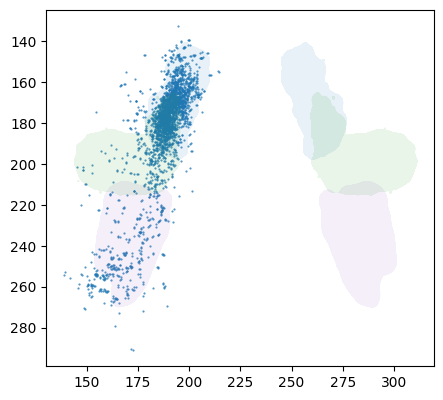

In [6]:
n_components = 3
cca, X_c, S_c = run_CCA(adata_mer, mesh_LC,n_components=n_components, visualize=True)
canonical_correlations = [np.corrcoef(X_c[:, i], S_c[:, i])[0, 1] for i in range(n_components)]
print("Canonical correlations:", canonical_correlations)

r2 = canonical_correlations.copy()

Text(0.5, 1.0, 'rotations')

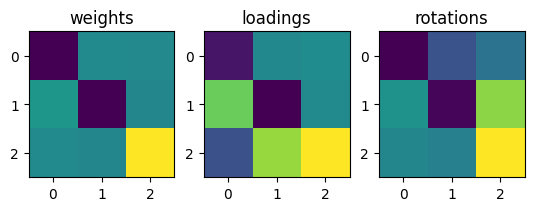

In [7]:
plt.subplot(1,3,1);plt.imshow(cca.y_weights_);plt.title('weights')
plt.subplot(1,3,2);plt.imshow(cca.y_loadings_);plt.title('loadings')
plt.subplot(1,3,3);plt.imshow(cca.y_rotations_);plt.title('rotations')

In [8]:
cca.y_weights_

array([[-0.99686632, -0.05273333, -0.05896389],
       [ 0.05737438, -0.99514184, -0.08000562],
       [-0.05445847, -0.08313792,  0.99504892]])

In [9]:
S_c.shape, X_c.shape

((2651, 3), (2651, 3))

In [10]:
canonical_correlations

[0.9269336291358435, 0.8906036820423087, 0.5925791999939386]

### notes
- X_c and S_c are now the canonical variates for X and S, respectively.


In [11]:
np.argmax(cca.x_weights_[:,0])  # for X

244

# gene components?
X_c. S_c are U and V correspondingly 

In [12]:
k = 0
cca.y_weights_[:,k]

array([-0.99686632,  0.05737438, -0.05445847])

In [13]:
k = 0
cca.y_weights_

array([[-0.99686632, -0.05273333, -0.05896389],
       [ 0.05737438, -0.99514184, -0.08000562],
       [-0.05445847, -0.08313792,  0.99504892]])

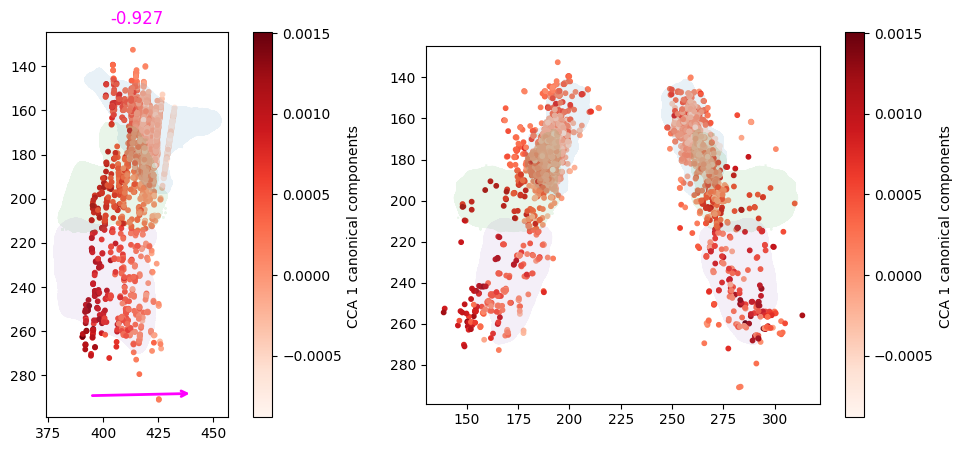

<Figure size 640x480 with 0 Axes>

In [17]:
k = 0
scale_factor =50 # Adjust this factor as needed
vector =(cca.y_weights_[:,k]) 
vector_scaled = vector * -scale_factor

plt.figure(figsize=(14, 5))
plt.subplot(1,2,1)
sca = plt.scatter(adata_mer.obsm['spatial'][:, 0], adata_mer.obsm['spatial'][:, 1], c=X_c[:, k],cmap='Reds',s=10)
cbar = plt.colorbar(sca, label=f'CCA {k+1} canonical components ')
plt.gca().set_aspect('equal')
start_point = (np.min(adata_mer.obsm['spatial'][:, 0]), np.max(adata_mer.obsm['spatial'][:, 1]))
end_point = (start_point[0] + vector_scaled[0], start_point[1] + vector_scaled[1])

plt.gca().triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
plt.gca().triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
plt.gca().triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
plt.gca().invert_yaxis()
plt.title("%.3f" %-canonical_correlations[k], color = 'magenta')
plt.annotate(' ',color='magenta',
             xy=end_point,   # arrow tip
             xytext=start_point,  # arrow tail
             arrowprops=dict(arrowstyle="->", color="magenta", lw=2)
            )


plt.subplot(1,2,2)
sca = plt.scatter(adata_mer.obsm['spatial'][:, 2], adata_mer.obsm['spatial'][:, 1], c=X_c[:, k],cmap='Reds',s=10)
cbar = plt.colorbar(sca, label=f'CCA {k+1} canonical components ')
plt.gca().set_aspect('equal')

plt.gca().triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
plt.gca().triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
plt.gca().triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
plt.gca().invert_yaxis()

plt.show()
plt.tight_layout()

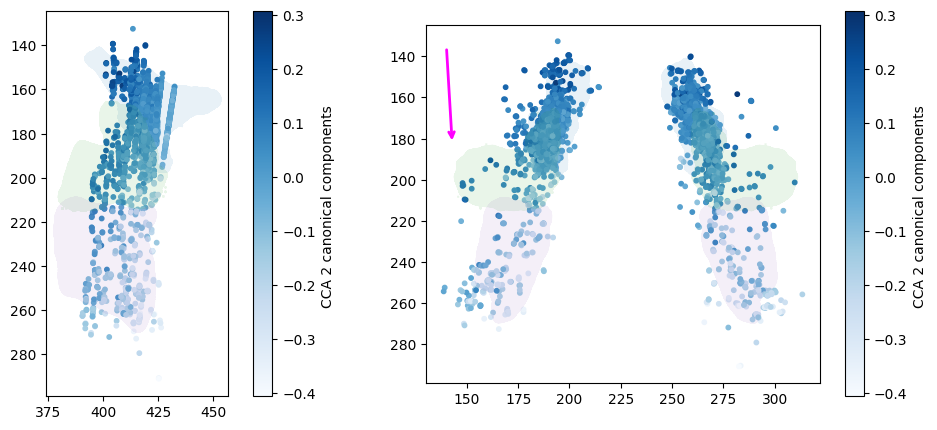

<Figure size 640x480 with 0 Axes>

In [15]:
k = 1
scale_factor = 50 # Adjust this factor as needed
vector =(cca.y_weights_[:,k]) 
vector_scaled = vector * -scale_factor

plt.figure(figsize=(14, 5))
plt.subplot(1,2,1)
sca = plt.scatter(adata_mer.obsm['spatial'][:, 0], adata_mer.obsm['spatial'][:, 1], c=X_c[:, k],cmap='Blues',s=10)
cbar = plt.colorbar(sca, label=f'CCA {k+1} canonical components ')
plt.gca().set_aspect('equal')
plt.gca().triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
plt.gca().triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
plt.gca().triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
plt.gca().invert_yaxis()



plt.subplot(1,2,2)

sca = plt.scatter(adata_mer.obsm['spatial'][:, 2], adata_mer.obsm['spatial'][:, 1], c=X_c[:, k],cmap='Blues',s=10)
cbar = plt.colorbar(sca, label=f'CCA {k+1} canonical components ')
plt.gca().set_aspect('equal')
start_point = (np.min(adata_mer.obsm['spatial'][:, 2]), np.min(adata_mer.obsm['spatial'][:, 1]))
end_point = (start_point[0] + vector_scaled[2], start_point[1] + vector_scaled[1])

plt.gca().triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
plt.gca().triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
plt.gca().triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
plt.title("" %-canonical_correlations[k])
plt.annotate(' ',color='magenta',
             xy=end_point,   # arrow tip
             xytext=start_point,  # arrow tail
             arrowprops=dict(arrowstyle="->", color="magenta", lw=2)
            )

plt.gca().invert_yaxis()



plt.show()
plt.tight_layout()

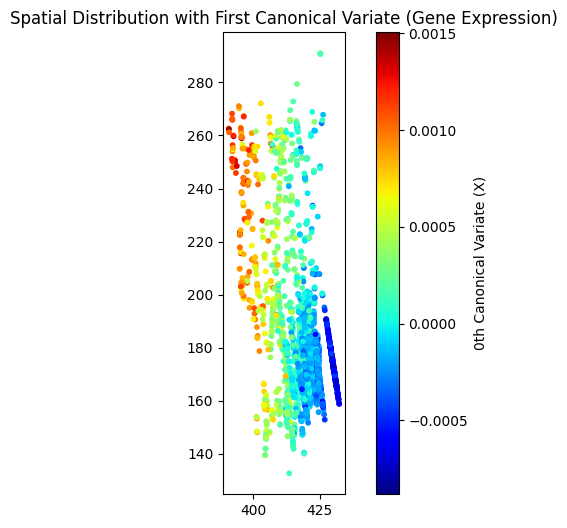

In [25]:
i = 0

plt.figure(figsize=(8, 6))
sc = plt.scatter(adata_mer.obsm['spatial'][:, 0], adata_mer.obsm['spatial'][:, 1], c=X_c[:, i],cmap='jet',s=10)
plt.title("Spatial Distribution with First Canonical Variate (Gene Expression)")
plt.colorbar(sc, label=f"{i}th Canonical Variate (X)")
plt.gca().set_aspect('equal')
plt.show()


In [26]:
import pandas as pd
import seaborn as sns
import scanpy as sc

In [27]:

gene_labels = [f"Gene {i}" for i in range(adata_mer.X.shape[1])]
gene_labels = list(adata_mer.var_names)

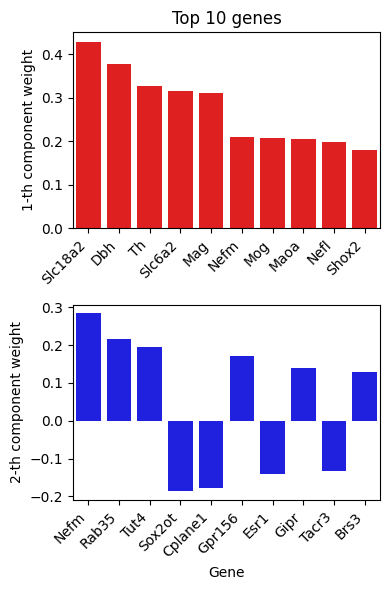

In [28]:
T = 10
k=0
loadings_1_df = pd.DataFrame({'gene': gene_labels,'loading': cca.x_weights_[:, k]})
loadings_1_df['abs_loading'] = loadings_1_df['loading'].abs()
loadings_1_sorted = loadings_1_df.sort_values('abs_loading', ascending=False)

plt.figure(figsize=(4,6))
plt.subplot(2,1,1)
sns.barplot(x='gene', y='loading', data=loadings_1_sorted.head(T), color = 'r')
plt.xticks(rotation=45, ha='right')
plt.xlabel("")
plt.ylabel(f"{k+1}-th component weight")
plt.title(f"Top {T} genes")
# plt.tight_layout()
# plt.show()


k=1
loadings_2_df = pd.DataFrame({'gene': gene_labels,'loading': cca.x_weights_[:, k]})
loadings_2_df['abs_loading'] = loadings_2_df['loading'].abs()
loadings_2_sorted = loadings_2_df.sort_values('abs_loading', ascending=False)

plt.subplot(2,1,2)
sns.barplot(x='gene', y='loading', data=loadings_2_sorted.head(T), color = 'b') 
plt.xticks(rotation=45, ha='right')
plt.xlabel("Gene")
plt.ylabel(f"{k+1}-th component weight")
# plt.title(f"Top {T} genes")
plt.tight_layout()
plt.show()

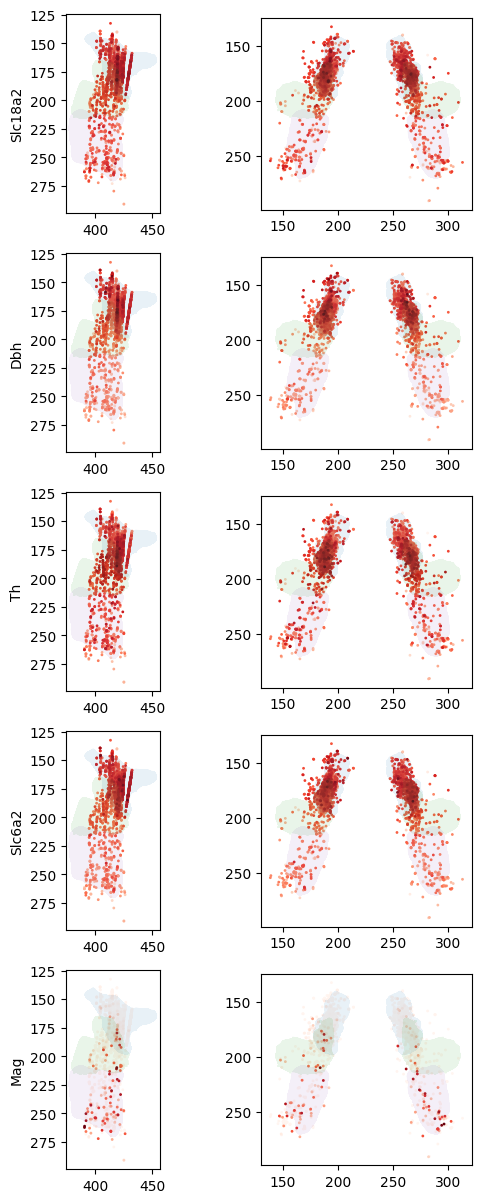

In [30]:
T = 5
fig, axes = plt.subplots(T,2,figsize=(6,3*T))

for i in range(T):
    top_gene = loadings_1_sorted.iloc[i]['gene']
    gene_index = list(adata_mer.var_names).index(top_gene)
    gene_expression = adata_mer.X[:, gene_index].toarray().flatten() if hasattr(adata_mer.X, "toarray") else adata_mer.X[:, gene_index]
    ordered = np.argsort(gene_expression)
    
    ax = axes[i,0]
    sc = ax.scatter(adata_mer.obsm['spatial'][ordered, 0], adata_mer.obsm['spatial'][ordered, 1], c=gene_expression[ordered], cmap='Reds',s=1)
    ax.set_title('')
    ax.set_aspect('equal')
    ax.triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
    ax.triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
    ax.triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
    ax.invert_yaxis()
    ax.set_ylabel(top_gene)

    ax = axes[i,1]
    sc = ax.scatter(adata_mer.obsm['spatial'][ordered, 2], adata_mer.obsm['spatial'][ordered, 1], c=gene_expression[ordered], cmap='Reds',s=1)
    ax.set_title('')
    ax.set_aspect('equal')
    ax.triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
    ax.triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
    ax.triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
    ax.invert_yaxis()




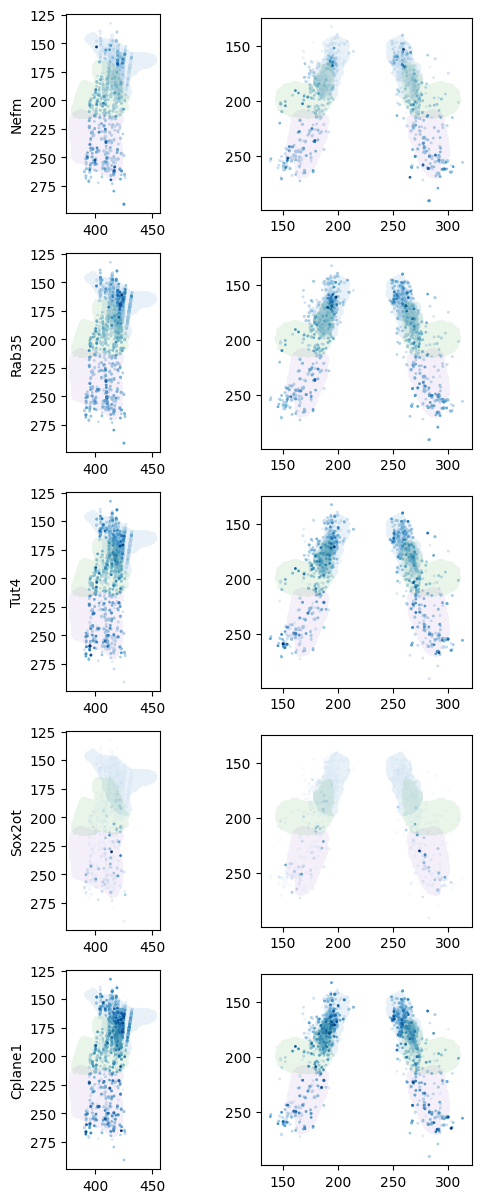

In [31]:
T = 5
fig, axes = plt.subplots(T,2,figsize=(6,3*T))

for i in range(T):
    top_gene = loadings_2_sorted.iloc[i]['gene']
    gene_index = list(adata_mer.var_names).index(top_gene)
    gene_expression = adata_mer.X[:, gene_index].toarray().flatten() if hasattr(adata_mer.X, "toarray") else adata_mer.X[:, gene_index]
    ordered = np.argsort(gene_expression)

    ax = axes[i,0]
    sc = ax.scatter(adata_mer.obsm['spatial'][ordered, 0], adata_mer.obsm['spatial'][ordered, 1], c=gene_expression[ordered], cmap='Blues',s=1)
    ax.set_title('')
    ax.set_aspect('equal')
    ax.triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
    ax.triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
    ax.triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
    ax.invert_yaxis()
    ax.set_ylabel(top_gene)

    ax = axes[i,1]
    sc = ax.scatter(adata_mer.obsm['spatial'][ordered, 2], adata_mer.obsm['spatial'][ordered, 1], c=gene_expression[ordered], cmap='Blues',s=1)
    ax.set_title('')
    ax.set_aspect('equal')
    ax.triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
    ax.triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
    ax.triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
    ax.invert_yaxis()

# they looks wrong.. so lets jsut do some correlation analysis 
(between axis and genes)

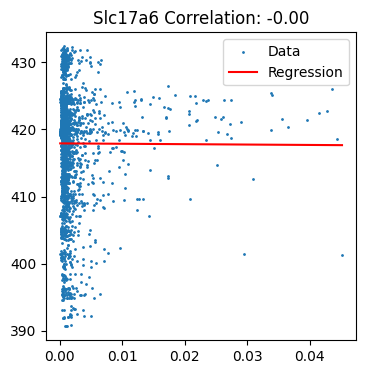

In [34]:
# for i in range(T):
i = 24

top_gene = loadings_1_sorted.iloc[i]['gene']
gene_index = list(adata_mer.var_names).index(top_gene)
gene_expression = adata_mer.X[:, gene_index].toarray().flatten() if hasattr(adata_mer.X, "toarray") else adata_mer.X[:, gene_index]
ordered = np.argsort(gene_expression)
# plt.figure(figsize=(3,3))
# plt.plot(gene_expression[ordered], '--')
# plt.ylabel(f'exresion of {top_gene}')


corr_coef = np.corrcoef(gene_expression, adata_mer.obsm['spatial'][:,0])[0, 1]
slope, intercept = np.polyfit(gene_expression, adata_mer.obsm['spatial'][:,0], 1)
x_vals = np.array([np.min(gene_expression), np.max(gene_expression)])
y_vals = slope * x_vals + intercept


plt.figure(figsize=(4,4))
plt.scatter(gene_expression, adata_mer.obsm['spatial'][:,0], s=1, label='Data')
plt.plot(x_vals, y_vals, color='red', label='Regression')
plt.legend()

plt.title(f'{top_gene} Correlation: {corr_coef:.2f}')

plt.show()

# CCA for each clusetrs

In [31]:
adata_mer.obs['leiden']

neuron_id
103685216640203968188516774531086347883    5
107556232960175669029944473037950900912    5
110143770882700220040132120043038831763    3
113385467015087615676147138608792183276    5
120882274368051877867511817169740490916    2
                                          ..
96119208577592618782594425212756632908     6
9623349862178950852359237543126573460      6
96245750577479322584616409396904825217     2
9744450250461526053237534442143333842      0
99055081123244552139194124219121354798     2
Name: leiden, Length: 2651, dtype: category
Categories (5, object): ['0', '2', '3', '5', '6']

In [34]:
import scanpy

/home/shuonan.chen/miniconda3/envs/allensdk/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


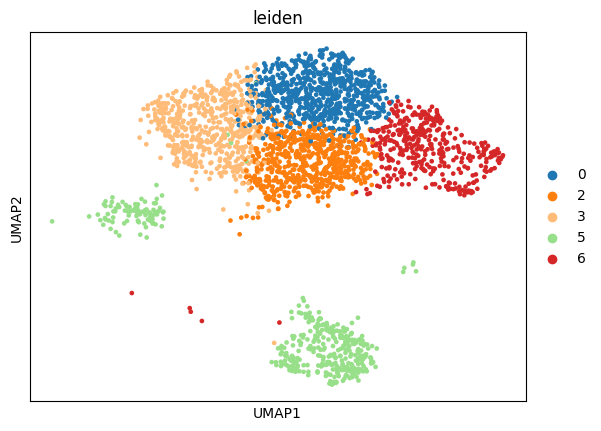

In [36]:
scanpy.pl.umap(adata_mer, color = 'leiden')

In [37]:
group_indices = list(adata_mer.obs.groupby('leiden').groups.values())

In [42]:
def run_CCA(adata, mesh_LC,n_components=3,visualize = False):
    X_mer = adata.X        # Gene expression matrix (2800 x 314)
    S_mer = adata.obsm['spatial']  # Spatial coordinates matrix, e.g., (2800 x 2)
    S_mer = get_hemi(S_mer, mesh_LC)    
    scaler_X = StandardScaler().fit(X_mer)
    X_mer_scaled = scaler_X.transform(X_mer)
    scaler_S = StandardScaler().fit(S_mer)
    S_mer_scaled = scaler_S.transform(S_mer)
    
    if visualize:
        plt.figure(figsize = (5,5))
        plt.scatter(S_mer[:,2], S_mer[:,1],s=.3, alpha =.8);
        plt.gca().set_aspect('equal')
        plt.gca().triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
        plt.gca().triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
        plt.gca().triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
        plt.gca().invert_yaxis()
        
    cca = CCA(n_components=n_components)
    cca.fit(X_mer_scaled, S_mer_scaled)
    X_c, S_c = cca.transform(X_mer_scaled, S_mer_scaled)

    return(cca, X_c, S_c)

In [47]:
groupid

Index(['281264827434562764427722750205696261394',
       '98471287826382116773773337560354818178',
       '127255798204451057592113089983566237482',
       '18743294847934269802793663898630680078',
       '20960644990655901054291166487406184828',
       '241555036271630660636844797379544542202',
       '280098102513794507825783657120190499281',
       '284708041978958849306179304301216066930',
       '84353574023608097695263837655228002360',
       '10331217527577646335100379177495939506',
       ...
       '318133594964724087869832580555440535151',
       '318385155520716544925909487999930209617',
       '35363437772007818419001038042247169660',
       '41714103526960127440502649815851339898',
       '48920893050778718287180123941772839385',
       '81229313457821020632610968877314832603',
       '86546670425137528051934194156989523544',
       '92982633794918225878507196396453575967',
       '96119208577592618782594425212756632908',
       '9623349862178950852359237543126573460'],
  

Canonical correlations: [0.9634035497787939, 0.8696326118628713, 0.7981288062258974]


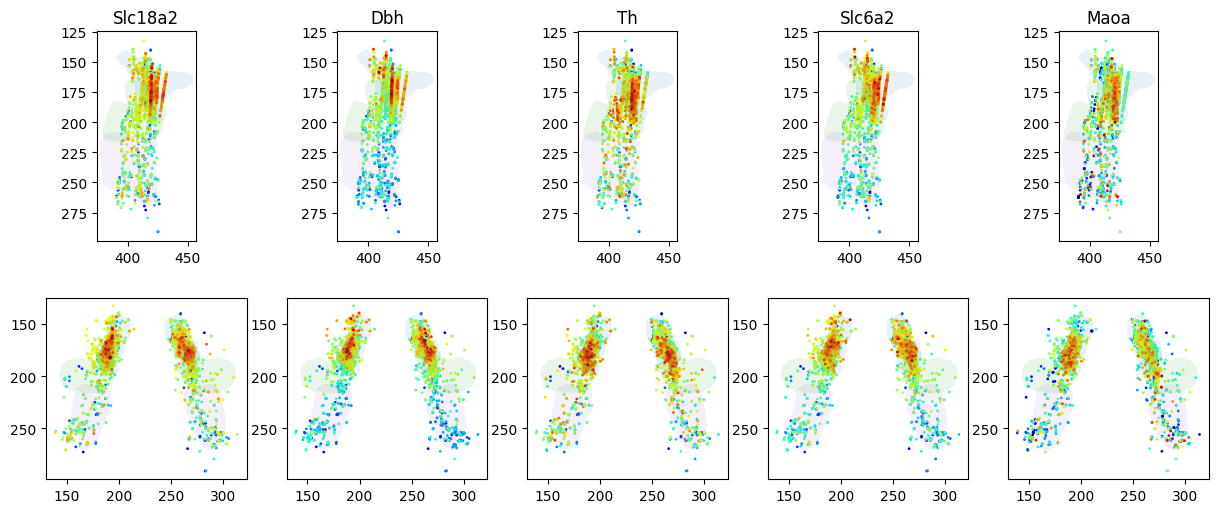

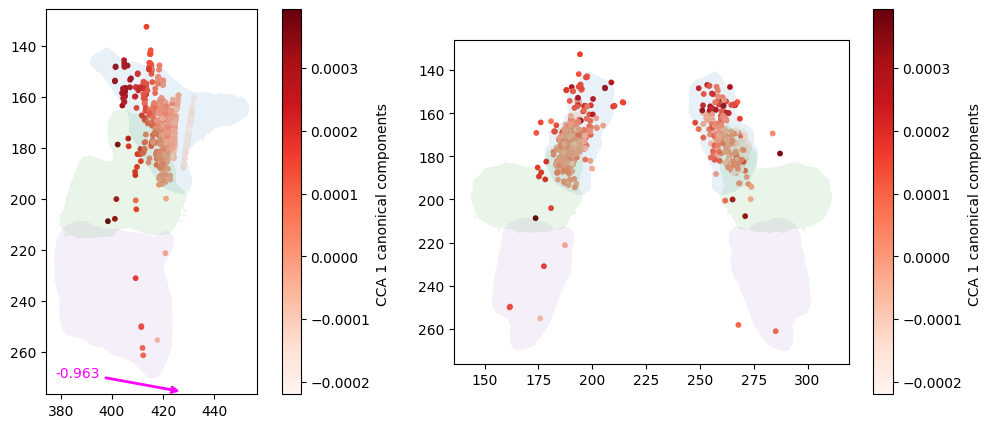

Canonical correlations: [0.9753880931320102, 0.8900456057523002, 0.8307512096091625]


<Figure size 640x480 with 0 Axes>

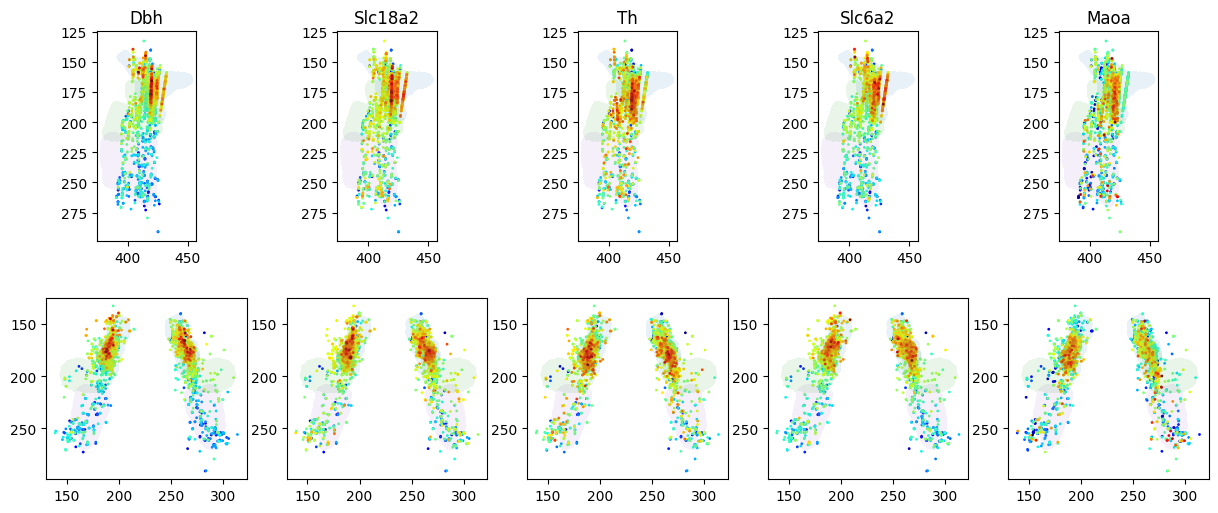

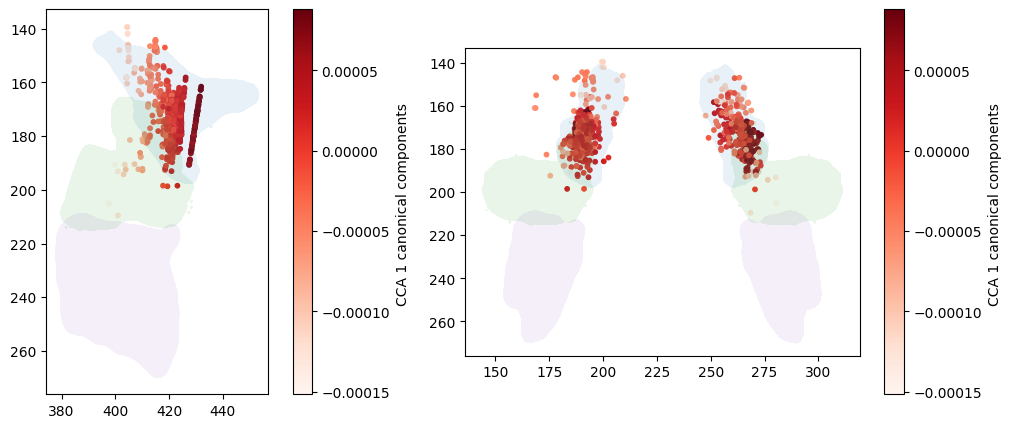

Canonical correlations: [0.9790432210943621, 0.8532099881769781, 0.8548841241262423]


<Figure size 640x480 with 0 Axes>

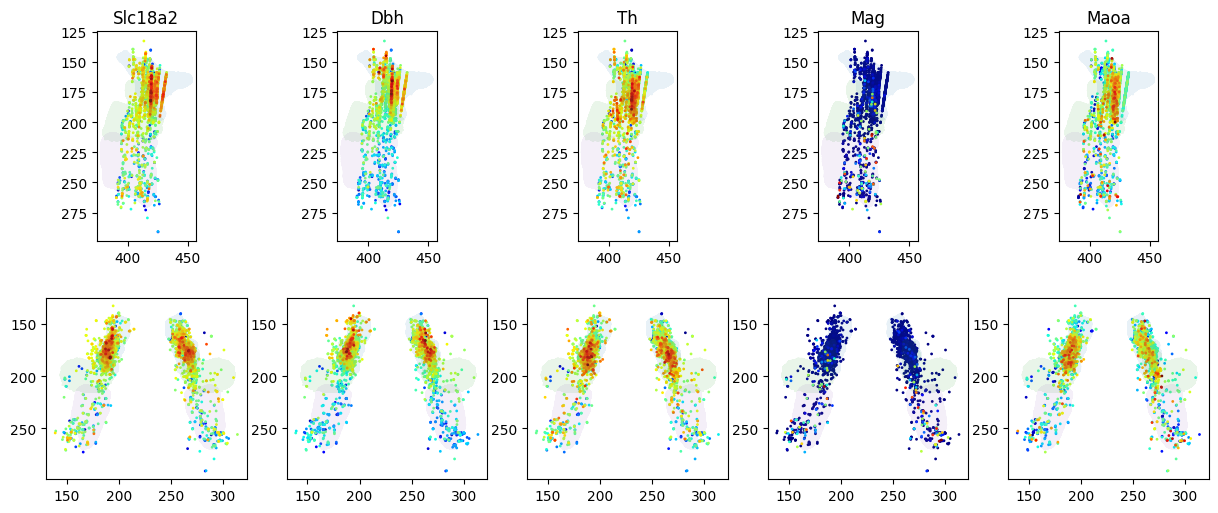

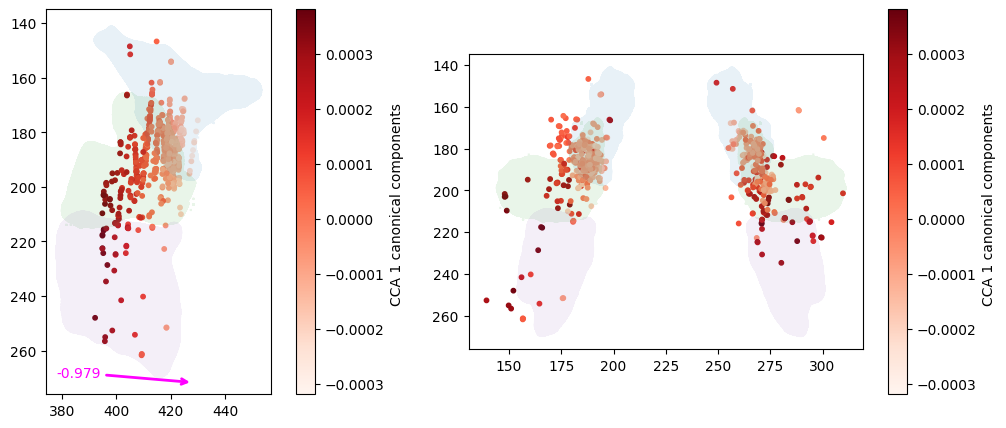

Canonical correlations: [0.9862716819130976, 0.9538422923472369, 0.9195124570350804]


<Figure size 640x480 with 0 Axes>

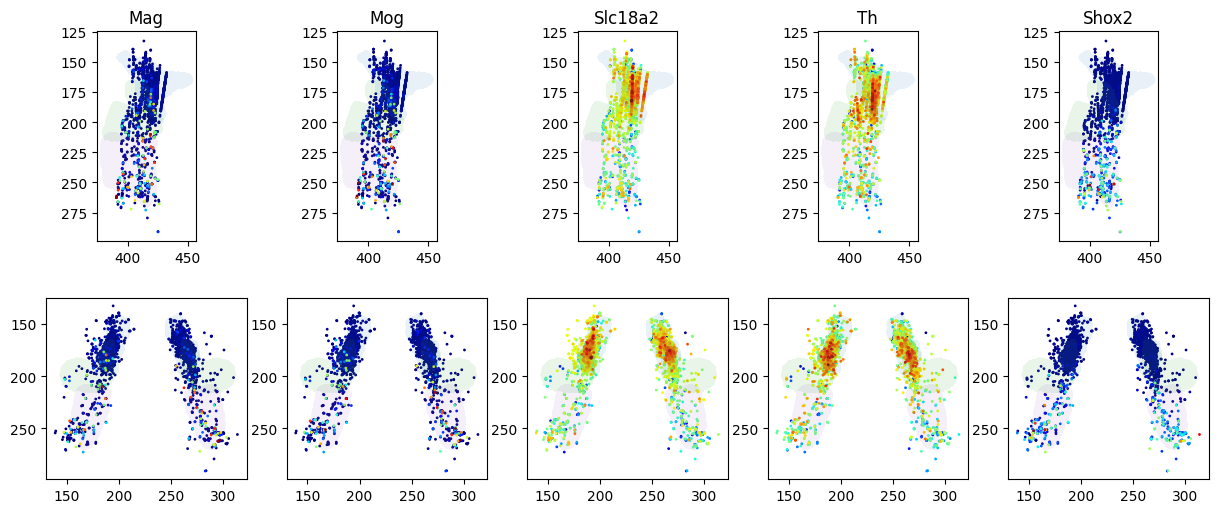

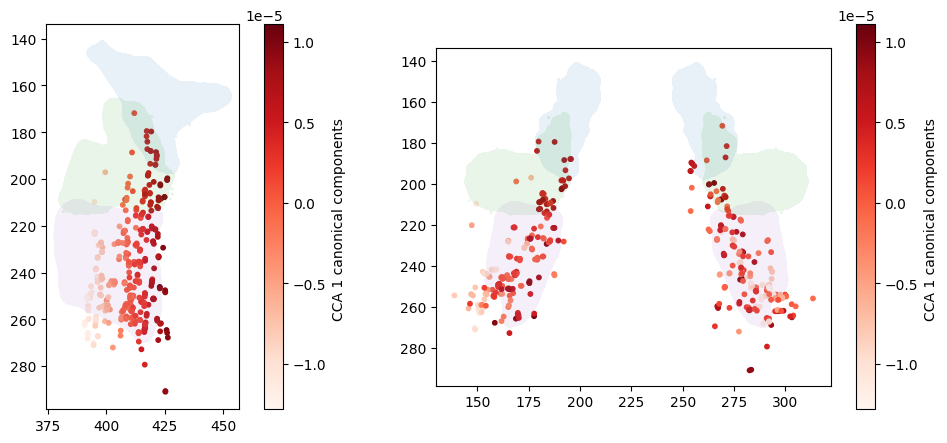

Canonical correlations: [0.9944781879301257, 0.9743206024248081, 0.9844624084679868]


<Figure size 640x480 with 0 Axes>

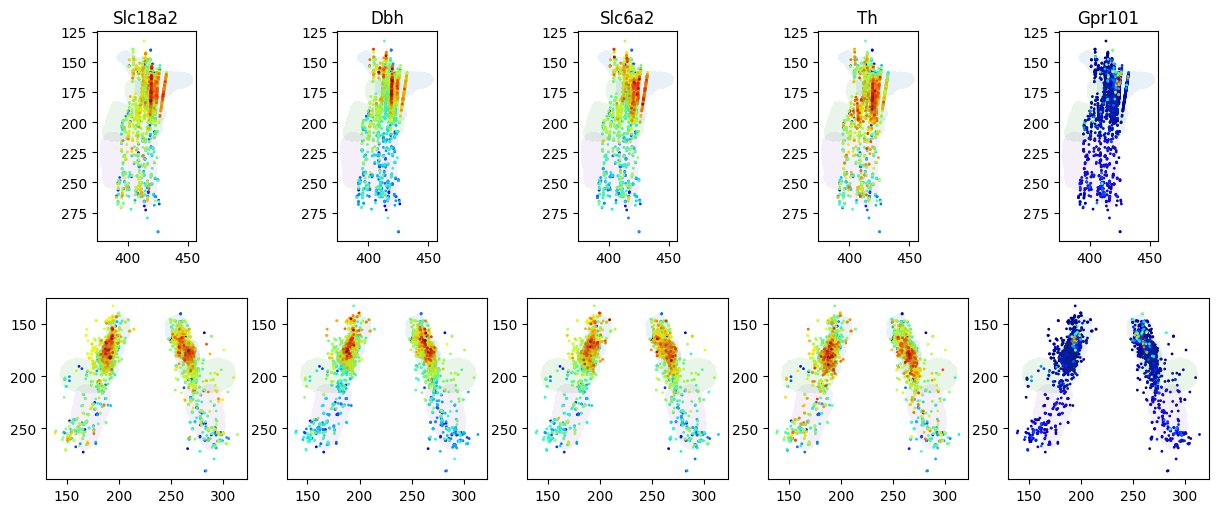

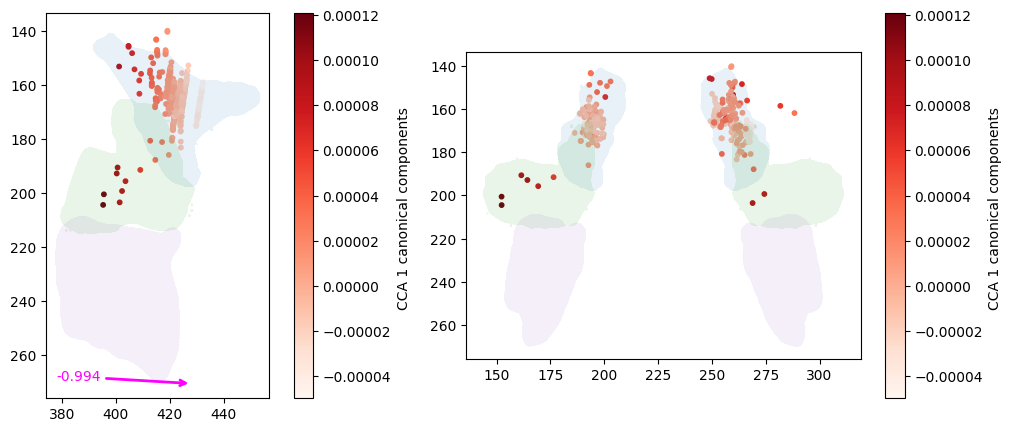

<Figure size 640x480 with 0 Axes>

In [57]:
n_components = 3

for groupid in group_indices:


    adata_sub = adata_mer[groupid]
    cca, X_c, S_c = run_CCA(adata_sub, mesh_LC,n_components=n_components, visualize=False)
    canonical_correlations = [np.corrcoef(X_c[:, i], S_c[:, i])[0, 1] for i in range(n_components)]
    print("Canonical correlations:", canonical_correlations)

    k = 0
    loadings_1_df = pd.DataFrame({'gene': gene_labels,'loading': cca.x_weights_[:, k]})
    loadings_1_df['abs_loading'] = loadings_1_df['loading'].abs()
    loadings_1_sorted = loadings_1_df.sort_values('abs_loading', ascending=False)

    T = 5
    fig, axes = plt.subplots(2,T,figsize=(3*T,6))

    for i in range(T):
        top_gene = loadings_1_sorted.iloc[i]['gene']
        gene_index = list(adata_mer.var_names).index(top_gene)
        gene_expression = adata_mer.X[:, gene_index].toarray().flatten() if hasattr(adata_mer.X, "toarray") else adata_mer.X[:, gene_index]
        ordered = np.argsort(gene_expression)

        ax = axes[0,i]
        sc = ax.scatter(adata_mer.obsm['spatial'][ordered, 0], adata_mer.obsm['spatial'][ordered, 1],
                        c=gene_expression[ordered], cmap='jet',s=1)
        ax.set_title('')
        ax.set_aspect('equal')
        ax.triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
        ax.triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
        ax.triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
        ax.invert_yaxis()
        ax.set_title(top_gene)

        ax = axes[1,i]
        sc = ax.scatter(adata_mer.obsm['spatial'][ordered, 2], adata_mer.obsm['spatial'][ordered, 1],
                        c=gene_expression[ordered], cmap='jet',s=1)
        ax.set_title('')
        ax.set_aspect('equal')
        ax.triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
        ax.triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
        ax.triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
        ax.invert_yaxis()


    scale_factor =50 # Adjust this factor as needed
    vector =(cca.y_weights_[:,k]) 
    vector_scaled = vector * -scale_factor

    plt.figure(figsize=(14, 5))
    plt.subplot(1,2,1)
    sca = plt.scatter(adata_sub.obsm['spatial'][:, 0], adata_sub.obsm['spatial'][:, 1], c=X_c[:, k],cmap='Reds',s=10)
    cbar = plt.colorbar(sca, label=f'CCA {k+1} canonical components ')
    plt.gca().set_aspect('equal')
    start_point = (np.min(mesh_CV.vertices.T[0]), np.max(mesh_CV.vertices.T[1]))
    end_point = (start_point[0] + vector_scaled[0], start_point[1] + vector_scaled[1])

    plt.gca().triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
    plt.gca().triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
    plt.gca().triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
    plt.gca().invert_yaxis()
    plt.annotate("%.3f" %-canonical_correlations[k],color='magenta',
                 xy=end_point,   # arrow tip
                 xytext=start_point,  # arrow tail
                 arrowprops=dict(arrowstyle="->", color="magenta", lw=2)
                )

    plt.subplot(1,2,2)
    sca = plt.scatter(adata_sub.obsm['spatial'][:, 2], adata_sub.obsm['spatial'][:, 1], c=X_c[:, k],cmap='Reds',s=10)
    cbar = plt.colorbar(sca, label=f'CCA {k+1} canonical components ')
    plt.gca().set_aspect('equal')
    plt.gca().triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
    plt.gca().triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
    plt.gca().triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
    plt.gca().invert_yaxis()

    plt.show()
    plt.tight_layout()
